<a href="https://www.kaggle.com/code/sonawanelalitsunil/olympic-medal-winners-1896-2024-ml-0-3519?scriptVersionId=227995583" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/olympics-medal-list-1896-2024/Olympics (1896-2024).csv


## Title: Olympic Medal Winners: 1896–2024 – Complete Historical List

#### Description: Explore the complete list of Olympic medalists from 1896 to 2024, covering all Summer and Winter Games. Discover country rankings, athlete achievements, and historical trends in Olympic history.

## Import dataset

In [2]:
df = pd.read_csv('/kaggle/input/olympics-medal-list-1896-2024/Olympics (1896-2024).csv')

In [3]:
df.head()

,Year,Rank,NOC,Gold,Silver,Bronze,Total
0,2024,1,United States,40,44,42,126
1,2024,2,China,40,27,24,91
2,2024,3,Japan,20,12,13,45
3,2024,4,Australia,18,19,16,53
4,2024,5,France,16,26,22,64


In [4]:
df.tail()

,Year,Rank,NOC,Gold,Silver,Bronze,Total
1431,1896,7,Austria,2,1,2,5
1432,1896,8,Australia,2,0,0,2
1433,1896,9,Denmark,1,2,3,6
1434,1896,10,Switzerland,1,2,0,3
1435,1896,11,Mixed team,1,0,1,2


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Year    1436 non-null   int64 
 1   Rank    1436 non-null   object
 2   NOC     1436 non-null   object
 3   Gold    1436 non-null   int64 
 4   Silver  1436 non-null   int64 
 5   Bronze  1436 non-null   int64 
 6   Total   1436 non-null   int64 
dtypes: int64(5), object(2)
memory usage: 78.7+ KB


In [6]:
df.describe()

,Year,Gold,Silver,Bronze,Total
count,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000
mean,1981.899721,4.053621,4.030641,4.392061,12.476323
std,34.119053,8.411742,7.115310,6.847175,21.641717
min,1896.000000,0.000000,0.000000,0.000000,1.000000
25%,1960.000000,0.000000,0.000000,1.000000,2.000000
50%,1992.000000,1.000000,2.000000,2.000000,5.000000
75%,2008.000000,4.000000,4.000000,5.000000,13.000000
max,2024.000000,83.000000,79.000000,78.000000,234.000000


In [7]:
df.isnull().sum()

Year      0
Rank      0
NOC       0
Gold      0
Silver    0
Bronze    0
Total     0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df.dtypes

Year       int64
Rank      object
NOC       object
Gold       int64
Silver     int64
Bronze     int64
Total      int64
dtype: object

In [10]:
df.corr

<bound method DataFrame.corr of       Year Rank            NOC  Gold  Silver  Bronze  Total
0     2024    1  United States    40      44      42    126
1     2024    2          China    40      27      24     91
2     2024    3          Japan    20      12      13     45
3     2024    4      Australia    18      19      16     53
4     2024    5         France    16      26      22     64
...    ...  ...            ...   ...     ...     ...    ...
1431  1896    7        Austria     2       1       2      5
1432  1896    8      Australia     2       0       0      2
1433  1896    9        Denmark     1       2       3      6
1434  1896   10    Switzerland     1       2       0      3
1435  1896   11     Mixed team     1       0       1      2

[1436 rows x 7 columns]>

In [11]:
df.shape

(1436, 7)

In [12]:
df.columns

Index(['Year', 'Rank', 'NOC', 'Gold', 'Silver', 'Bronze', 'Total'], dtype='object')

## Data visualizations

In [13]:
# Convert 'Year' to categorical for proper visualization
df['Year'] = df['Year'].astype(int)

# Set default color palette
sns.set_palette(["darkblue", "darkgreen", "darkred"])

<Figure size 1200x600 with 0 Axes>

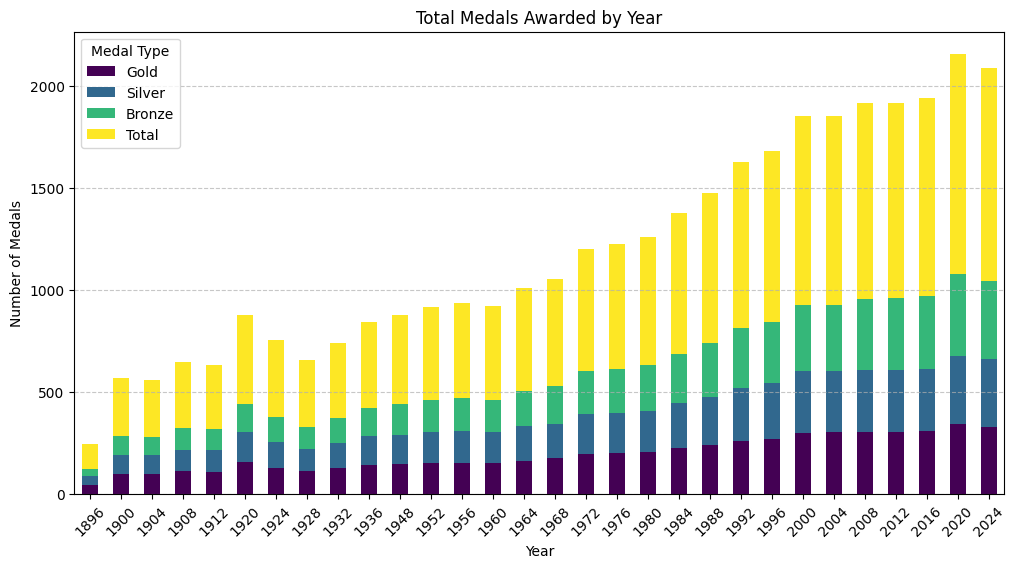

In [14]:
# 1. Total medals by year
plt.figure(figsize=(12, 6))
medals_by_year = df.groupby('Year')[['Gold', 'Silver', 'Bronze', 'Total']].sum()
medals_by_year.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='viridis')
plt.title("Total Medals Awarded by Year")
plt.xlabel("Year")
plt.ylabel("Number of Medals")
plt.legend(title="Medal Type")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.show()

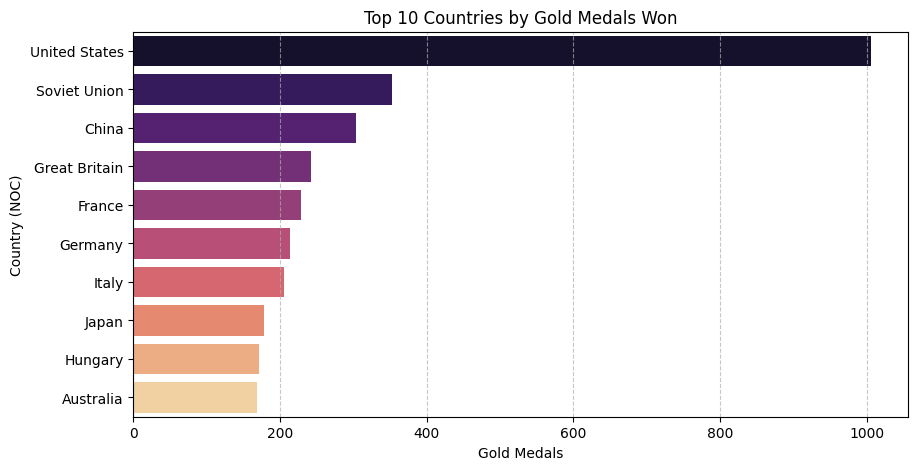

In [15]:
# 2. Top 10 countries with most gold medals
top_countries = df.groupby("NOC")["Gold"].sum().nlargest(10)
plt.figure(figsize=(10, 5))
sns.barplot(x=top_countries.values, y=top_countries.index, palette="magma")
plt.title("Top 10 Countries by Gold Medals Won")
plt.xlabel("Gold Medals")
plt.ylabel("Country (NOC)")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

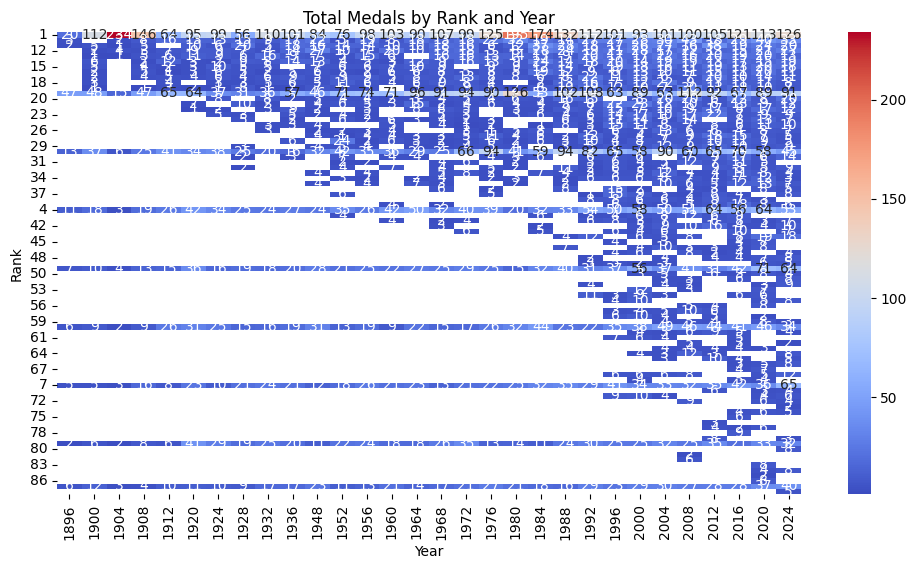

In [16]:
# 3. Rank vs Total Medals Heatmap (Fixing duplicate entries issue)
plt.figure(figsize=(12, 6))

# Aggregate by Rank and Year to avoid duplicates
pivot_df = df.groupby(['Rank', 'Year'])['Total'].sum().unstack()

sns.heatmap(pivot_df, cmap='coolwarm', annot=True, fmt=".0f")
plt.title("Total Medals by Rank and Year")
plt.xlabel("Year")
plt.ylabel("Rank")
plt.show()


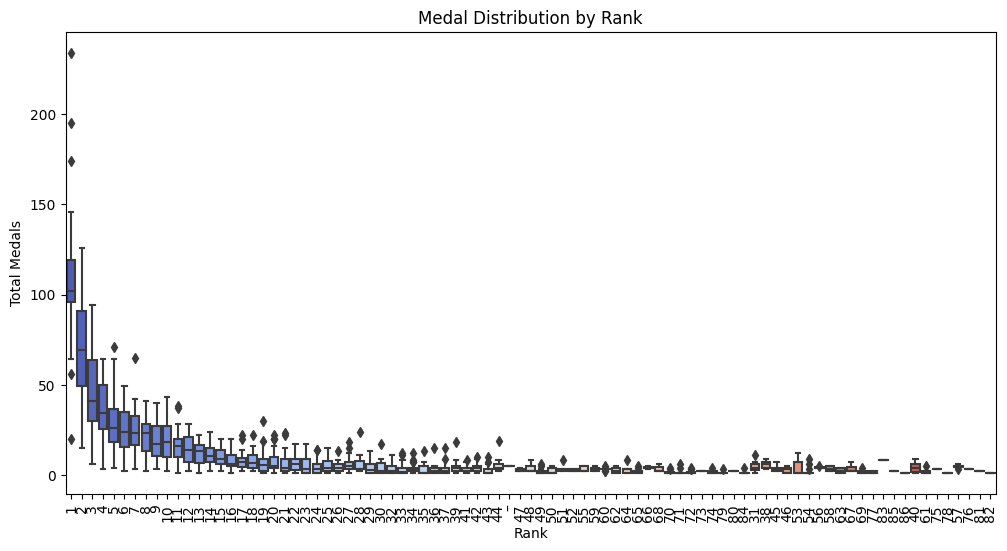

In [17]:
# 4. Medal Distribution by Rank
plt.figure(figsize=(12, 6))
sns.boxplot(x=df['Rank'], y=df['Total'], palette='coolwarm')
plt.title("Medal Distribution by Rank")
plt.xlabel("Rank")
plt.ylabel("Total Medals")
plt.xticks(rotation=90)
plt.show()

Year       int64
Rank      object
NOC       object
Gold       int64
Silver     int64
Bronze     int64
Total      int64
dtype: object
Year  1896   1900   1904   1908  1912  1920  1924  1928   1932   1936  ...  \
Rank                                                                   ...   
1     20.0  112.0  234.0  146.0  64.0  95.0  99.0  56.0  110.0  101.0  ...   
2     47.0   48.0   15.0   47.0  65.0  64.0  37.0  31.0   36.0   57.0  ...   
3     13.0   37.0    6.0   25.0  41.0  34.0  38.0  25.0   20.0   16.0  ...   
4     11.0   18.0    3.0   19.0  26.0  42.0  34.0  25.0   24.0   27.0  ...   
5      7.0   10.0    4.0   13.0  15.0  36.0  16.0  19.0   18.0   20.0  ...   

Year   1988   1992   1996  2000   2004   2008   2012   2016   2020   2024  
Rank                                                                       
1     132.0  112.0  101.0  93.0  101.0  100.0  105.0  121.0  113.0  126.0  
2     102.0  108.0   63.0  89.0   63.0  112.0   92.0   67.0   89.0   91.0  
3      94.0   82

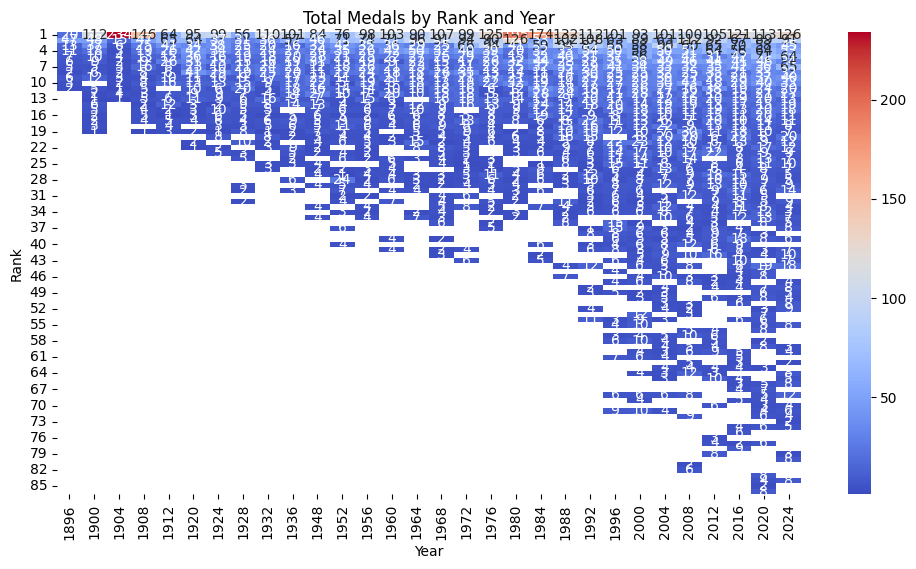

In [18]:
# Check data types
print(df.dtypes)

# Ensure 'Rank' and 'Year' are treated as integers
df['Rank'] = pd.to_numeric(df['Rank'], errors='coerce')
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')

# Drop NaN values that may arise due to conversion issues
df = df.dropna(subset=['Rank', 'Year', 'Total'])

# Convert back to int after cleaning
df['Rank'] = df['Rank'].astype(int)
df['Year'] = df['Year'].astype(int)

# Reattempt heatmap
plt.figure(figsize=(12, 6))
pivot_df = df.groupby(['Rank', 'Year'])['Total'].sum().unstack()

# Check if pivot table is empty
print(pivot_df.head())

if pivot_df.isnull().all().all():
    print("Pivot table is empty after grouping. Check data source.")
else:
    sns.heatmap(pivot_df, cmap='coolwarm', annot=True, fmt=".0f")
    plt.title("Total Medals by Rank and Year")
    plt.xlabel("Year")
    plt.ylabel("Rank")
    plt.show()


## predictive modeling

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

In [20]:
# Check data types
print(df.dtypes)

Year       int64
Rank       int64
NOC       object
Gold       int64
Silver     int64
Bronze     int64
Total      int64
dtype: object


In [21]:
# Convert 'Year' to numerical
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')

In [22]:
# Label encode categorical column 'NOC' (Country Code)
encoder = LabelEncoder()
df['NOC'] = encoder.fit_transform(df['NOC'])

In [23]:
# Drop rows with NaN values if any
df = df.dropna()

In [24]:
# Features (X) and Target (y)
X = df[['Year', 'NOC', 'Gold', 'Silver', 'Bronze', 'Total']]
y = df['Rank']  # Target variable

In [25]:
# Standardize numerical features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [26]:
# Train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [27]:
# List of ML Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier(),
    "Gradient Boosting": GradientBoostingClassifier()
}

In [28]:
# Train and Evaluate Each Model
results = {}

In [29]:
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    results[name] = accuracy
    print(f"\n{name} Accuracy: {accuracy:.4f}")
    print(classification_report(y_test, y_pred))



Logistic Regression Accuracy: 0.1150
              precision    recall  f1-score   support

           1       1.00      0.83      0.91         6
           2       1.00      0.80      0.89         5
           3       0.40      0.50      0.44         4
           4       0.25      0.14      0.18         7
           5       0.00      0.00      0.00         5
           6       0.08      0.25      0.12         4
           7       0.00      0.00      0.00         6
           8       0.00      0.00      0.00         5
           9       0.00      0.00      0.00         8
          10       0.14      0.67      0.24         3
          11       0.00      0.00      0.00         5
          12       0.00      0.00      0.00         3
          13       0.00      0.00      0.00         6
          14       0.00      0.00      0.00         6
          15       0.00      0.00      0.00         5
          16       0.00      0.00      0.00        11
          17       0.08      0.12      0.10

In [30]:
# Classification Report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       1.00      0.83      0.91         6
           2       1.00      0.80      0.89         5
           3       0.22      0.50      0.31         4
           4       0.33      0.14      0.20         7
           5       0.00      0.00      0.00         5
           6       0.00      0.00      0.00         4
           7       0.33      0.17      0.22         6
           8       0.20      0.20      0.20         5
           9       0.40      0.25      0.31         8
          10       0.11      0.33      0.17         3
          11       0.20      0.20      0.20         5
          12       0.00      0.00      0.00         3
          13       0.00      0.00      0.00         6
          14       0.00      0.00      0.00         6
          15       0.00      0.00      0.00         5
          16       0.20      0.09      0.13        11
          17       0.00      0.00      0.00         8
          18       0.00    

In [31]:
best_model = max(results, key=results.get)
print(f"\nBest Model: {best_model} with Accuracy: {results[best_model]:.4f}")


Best Model: Decision Tree with Accuracy: 0.3484


## Thank you!!! ...pls upvote!!!